## Load all reference data

In [1]:
import pandas as pd
from pathlib import Path

d = Path.cwd()
if d == Path('C:/git/RailwAI/code'):
    root = d.parent
elif d == Path('C:/git/RailwAI'):
    root = d
else:
    print('ERROR: you are actually in ' + str(Path.cwd()))

video_root = root / "VIDEO"

dfs = []

for csv_file in video_root.rglob("reference_video.csv"):
    print("Loading:", csv_file)

    df_tmp = pd.read_csv(csv_file, sep=";")

    # Ajouter la date depuis le dossier parent
    df_tmp["datum"] = csv_file.parent.name

    dfs.append(df_tmp)

# Vérification si aucun fichier trouvé
if len(dfs) == 0:
    raise FileNotFoundError("No reference_video.csv in VIDEO")

# Fusion de tous les jours
df_reference_all = pd.concat(
    dfs,
    ignore_index=True
)

df_reference_all.head()

Loading: c:\git\RailwAI\VIDEO\20260304\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260305\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260306\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260307\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260308\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260309\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260611\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260612\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260613\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260614\reference_video.csv
Loading: c:\git\RailwAI\VIDEO\20260615\reference_video.csv


,video,train_class,train_type,datum
0,c:\git\RailwAI\VIDEO\20260304\ADTC Rueschlikon...,DPZ,Lok,20260304
1,c:\git\RailwAI\VIDEO\20260304\ADTC Rueschlikon...,DTZ,Trieb,20260304
2,c:\git\RailwAI\VIDEO\20260304\ADTC Rueschlikon...,DTZ,Trieb,20260304
3,c:\git\RailwAI\VIDEO\20260304\ADTC Rueschlikon...,DTZ,Trieb,20260304
4,c:\git\RailwAI\VIDEO\20260304\ADTC Rueschlikon...,DPZ,Lok,20260304


## Join the CWT images and the reference labels

In [2]:
import pandas as pd
from pathlib import Path

d = Path.cwd()
if d == Path('C:/git/RailwAI/code'):
    root = d.parent
elif d == Path('C:/git/RailwAI'):
    root = d
else:
    print('ERROR: you are actually in ' + str(Path.cwd()))

dataframe_video_dir = root / "DataframeVideo"

df_all = []

for csv_file in dataframe_video_dir.glob("*.csv"):
    df_all.append(pd.read_csv(csv_file))

df_video_merged = pd.concat(
    df_all,
    ignore_index=True
)


img_dir = root / "images" / "combined"

df_dataset = df_video_merged.copy()

df_dataset["image_path"] = df_dataset["file"].apply(
    lambda x: str(img_dir / f"{x}.png")
)

df_dataset = df_dataset[
    df_dataset["image_path"].apply(lambda x: Path(x).exists())
    &
    df_dataset["train_type"].notna()
][
    ["file", "image_path", "train_type"]
]

df_dataset = df_dataset.drop_duplicates(
    subset=["image_path"]
)

print("Dataset final :", len(df_dataset))

df_dataset.head()

Dataset final : 766


,file,image_path,train_type
0,ADTC_8_adz_raw_20260304_1430,c:\git\RailwAI\images\combined\ADTC_8_adz_raw_...,Lok
1,ADTC_8_adz_raw_20260304_1440,c:\git\RailwAI\images\combined\ADTC_8_adz_raw_...,Trieb
2,ADTC_8_adz_raw_20260304_1500,c:\git\RailwAI\images\combined\ADTC_8_adz_raw_...,Trieb
3,ADTC_8_adz_raw_20260304_1510,c:\git\RailwAI\images\combined\ADTC_8_adz_raw_...,Trieb
4,ADTC_8_adz_raw_20260304_1530,c:\git\RailwAI\images\combined\ADTC_8_adz_raw_...,Lok


# Data split (train, val, test)

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

X = df_dataset['image_path']
y = df_dataset['train_type']

X_train, X_rest, y_train, y_rest = train_test_split(X, y, train_size=0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, train_size=0.5, random_state=42)

print('Training data:', len(X_train))
print('Validation data:', len(X_val))
print('Test data:', len(X_test))

# copy the files into the train/val/test folders
dst_path = 'C:/git/RailwAI/images/AI-train'

if os.path.exists(dst_path):
    shutil.rmtree(dst_path)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dst_path, split), exist_ok=True)

def copy_images(X_split, y_split, split_name):
    split_dir = os.path.join(dst_path, split_name)

    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)

    os.makedirs(split_dir, exist_ok=True)

    for img_path, train_type in zip(X_split, y_split):
        class_dir = os.path.join(split_dir, train_type)
        os.makedirs(class_dir, exist_ok=True)

        shutil.copy(img_path, class_dir)

    return split_dir

train_dir = copy_images(X_train, y_train, 'train')
val_dir = copy_images(X_val, y_val, 'val')
test_dir = copy_images(X_test, y_test, 'test')

Training data: 536
Validation data: 115
Test data: 115


In [4]:
# train_dir = 'C:/git/RailwAI/images/AI-train/train'
# val_dir = 'C:/git/RailwAI/images/AI-train/val'
# test_dir = 'C:/git/RailwAI/images/AI-train/test'
# inference_dir = 'C:/git/RailwAI/images/inference'

## Dataset and DataLoader Setup

In [5]:
from dataset import CustomImageDataset

from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # values from efficientnet_b3
                         std=[0.229, 0.224, 0.225]), # values from efficientnet_b3
])

train_dataset = CustomImageDataset(img_dir=train_dir, transform=transform)
val_dataset = CustomImageDataset(img_dir=val_dir, transform=transform)
test_dataset = CustomImageDataset(img_dir=test_dir, transform=transform)

batchsize = 8

train_dataloader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# check the classes
print('Number of classes: ', len(train_dataset.classes))
print(train_dataset.class_to_idx)

Number of classes:  2
{'Lok': 0, 'Trieb': 1}


## Model training

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import f1_score

from pathlib import Path

model_dir = Path("model")
model_dir.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# csv_file = "training_log_no_random.csv"
# with open(csv_file, mode="w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["Epoch", "LR", "train_acc", "train_loss", "val_acc", "val_loss", "f1_score"]) # header

# https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b5.html#torchvision.models.EfficientNet_B5_Weights
weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model = efficientnet_b3(weights=weights)
print(f'Pretrained weights {weights} loaded successfully')

num_classes = len(train_dataset.classes)
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(in_features, num_classes)
model.to(device) # send it to GPU

criterion = nn.CrossEntropyLoss()
initial_lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=initial_lr)
scheduler = StepLR(optimizer=optimizer, step_size=1 ,gamma=0.95)

num_epochs = 20
print(f'Training starts for {num_epochs} epochs')
print('')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels, _ in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        # loss calculation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # accuracy calculation
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0) #  total number of labels

    train_loss = running_loss/len(train_dataloader)
    train_acc = correct/total

    model.eval()
    # reinitialize for the validdation
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels, _ in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            # uses no gradient (no_grad), so no optimizer needed
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    val_loss = running_loss / len(val_dataloader)
    val_acc = correct / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    val_f1 = f1_score(all_labels, all_preds, average="weighted")

    # write in the CSV
    current_lr = optimizer.param_groups[0]['lr']
    
    # with open(csv_file, mode="a", newline="") as f:
    #     writer = csv.writer(f)
    #     writer.writerow([epoch+1, current_lr, train_acc, train_loss, val_acc, val_loss, val_f1])
    
    # print infos
    print(f"train_acc: {train_acc:.4f} - train_loss: {train_loss:.4f} - val_acc: {val_acc:.4f} - val_loss: {val_loss:.4f} - f1_score: {val_f1:.4f}")

    scheduler.step() # scheduler update

# save the first epoch as checkpoint and then always when the val_acc is better than the actual saved checkpoint, replace it:
    if (epoch + 1) == 1:
    best_f1 = val_f1
    output_name = model_dir / "efficientnet_b3_traintyp.pth"
    torch.save(model.state_dict(), output_name)
    print(f"Checkpoint for epoch {epoch + 1} saved as: {output_name}")

    else:
        if val_f1 > best_f1:
            best_f1 = val_f1
            output_name = model_dir / "efficientnet_b3_traintyp.pth"
            torch.save(model.state_dict(), output_name)
            print(f"Checkpoint for epoch {epoch + 1} saved as: {output_name}")
        else:
            pass

print('Model training is done')

Pretrained weights EfficientNet_B3_Weights.IMAGENET1K_V1 loaded successfully
Training starts for 20 epochs



Epoch 1/20 - Validation: 100%|██████████| 15/15 [00:03<00:00,  3.76it/s]


train_acc: 0.8937 - train_loss: 0.3066 - val_acc: 0.9652 - val_loss: 0.1356 - f1_score: 0.9652
Checkpoint for epoch 1  saved as: efficientnet_b3_traintyp.pth


Epoch 2/20 - Validation: 100%|██████████| 15/15 [00:02<00:00,  7.50it/s]


train_acc: 0.9907 - train_loss: 0.0752 - val_acc: 0.9652 - val_loss: 0.1263 - f1_score: 0.9652


...

train_acc: 1.0000 - train_loss: 0.0021 - val_acc: 0.9652 - val_loss: 0.2001 - f1_score: 0.9652


Epoch 19/20 - Validation: 100%|██████████| 15/15 [00:01<00:00,  7.76it/s]


train_acc: 1.0000 - train_loss: 0.0019 - val_acc: 0.9652 - val_loss: 0.1993 - f1_score: 0.9652


Epoch 20/20 - Validation: 100%|██████████| 15/15 [00:01<00:00,  7.91it/s]


train_acc: 1.0000 - train_loss: 0.0009 - val_acc: 0.9652 - val_loss: 0.2026 - f1_score: 0.9652
Model training is done


## Load the trained model

In [7]:
import torch
import torch.nn as nn

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"

# pretrained weights
weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model = efficientnet_b3(weights=weights)

num_features = model.classifier[1].in_features  # 2048 for B5
model.classifier[1] = nn.Linear(num_features, 2)  # 3 = number of classes

# fine-tuned checkpoint
model.load_state_dict(torch.load("efficientnet_b3_traintyp.pth", map_location=device))
model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

## Results on test data


Test Accuracy: 0.9826

F1 Score: 0.9826


[]

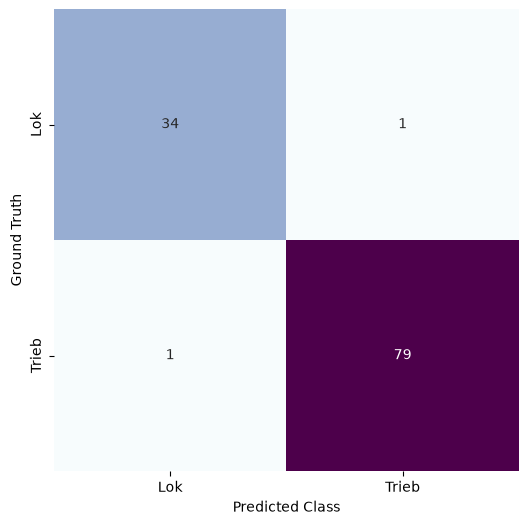

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load("efficientnet_b3_traintyp.pth", map_location=device))
model.to(device)
model.eval()  # evaluation mode

correct = 0
total = 0

all_preds = []
all_labels = []

classes = list(train_dataset.class_to_idx.keys())

ims = {}
i = 0

with torch.no_grad():
    for imgs, labels, paths in test_dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        probs = torch.softmax(outputs, dim=1)

        for path, pred, prob in zip(paths, preds, probs):
            pred_class = classes[pred]                 # get class name
            pred_prob = float(torch.max(prob) * 100)   # probability for predicted class

            ims[i] = {
                "path": path,
                "class": pred_class,
                "proba": pred_prob
            }
            i += 1
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nF1 Score: {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds, normalize=None)

plt.figure(figsize=(6,6))
sns.heatmap(cm, cmap='BuPu', annot=True, cbar=False, xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('Ground Truth')
plt.plot()